In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

TRAMOS = Path("../data/gold/tramos")
SALIDA = Path("../data/gold/mascaras")
SALIDA.mkdir(parents=True, exist_ok=True)

leer = lambda f: pd.read_csv(TRAMOS / f, index_col="Time_dt", parse_dates=["Time_dt", "Time_original"])
ajuste = leer("tramo_ajuste_2018.csv")
evaluacion = leer("tramo_evaluacion_2019.csv")
variables = [c for c in ajuste.columns if c != "Time_original"]

# Sensores físicos: cuando un equipo falla, fallan todas sus variables a la vez
GRUPOS = {
    "interior":        ["Indoor Temperature(°C)", "Indoor Humidity(%)"],
    "termohigrometro": ["Outdoor Temperature(°C)", "Outdoor Humidity(%)", "DewPoint(°C)", "WindChill(°C)"],
    "barometro":       ["Relative Pressure(hpa)", "Absolute Pressure(hpa)"],
    "anemometro":      ["Wind Speed(km/h)", "Gust(km/h)"],
    "pluviometro":     ["Hour Rainfall(mm)"],
    "luz":             ["Light(lux)"],
}
assert sorted(sum(GRUPOS.values(), [])) == sorted(variables)

PATRONES = ["overlap", "disjoint"]
Q = [1, 3, 6]                                                        # sensores físicos afectados
DURACIONES = {"1h": 2, "6h": 12, "1d": 48, "3d": 144, "7d": 336}   # en filas de 30 min
PORCENTAJES = [5, 10, 20, 30, 40, 50]                                # % de las celdas del tramo
TOLERANCIA = 2                                                       # puntos de % permitidos entre objetivo y real

In [2]:
def inicios_de_bloques(rng, m, k, p):
    """k bloques de p filas, sin traslaparse entre sí, dentro de m filas."""
    s = np.sort(rng.choice(m - k * p + 1, size=k, replace=False))
    return s + np.arange(k) * p


def generar_mascara(m, patron, q, p, pct, rng):
    """True = valor oculto. Devuelve None si la combinación es imposible."""
    for _ in range(200):                          # se sortean los sensores hasta que el objetivo sea alcanzable
        grupos = list(rng.choice(list(GRUPOS), size=q, replace=False))
        n_cols = sum(len(GRUPOS[g]) for g in grupos)
        k = int(round(pct / 100 * m * len(variables) / (n_cols * p)))   # bloques por sensor
        real = k * p * n_cols / (m * len(variables)) * 100
        if k >= 1 and m - k * p + 1 >= k and abs(real - pct) <= TOLERANCIA:
            break
    else:
        return None
    mascara = np.zeros((m, len(variables)), dtype=bool)
    comunes = inicios_de_bloques(rng, m, k, p)                      # los usa overlap
    for g in grupos:
        cols = [variables.index(c) for c in GRUPOS[g]]
        inicios = comunes if patron == "overlap" else inicios_de_bloques(rng, m, k, p)
        for s in inicios:
            mascara[s:s + p, cols] = True
    return mascara, grupos, k


def generar_conjunto(m, semillas):
    info, mascaras = [], []
    for patron in PATRONES:
        for q in Q:
            if patron == "overlap" and q == 1:      # con un solo sensor no hay nada que traslapar
                continue
            for dur, p in DURACIONES.items():
                for pct in PORCENTAJES:
                    for s in semillas:
                        rng = np.random.default_rng([s, PATRONES.index(patron), q, p, pct])
                        res = generar_mascara(m, patron, q, p, pct, rng)
                        if res is None:
                            continue
                        mascara, grupos, k = res
                        info.append(dict(id=len(mascaras), patron=patron, q=q, duracion=dur,
                                         filas_bloque=p, pct_objetivo=pct,
                                         pct_real=round(mascara.mean() * 100, 2),
                                         bloques_por_sensor=k, sensores="|".join(grupos), semilla=s))
                        mascaras.append(mascara)
    return pd.DataFrame(info), np.stack(mascaras)

In [3]:
info_aj, masc_aj = generar_conjunto(len(ajuste), semillas=range(1, 11))          # v1
info_ev, masc_ev = generar_conjunto(len(evaluacion), semillas=range(101, 111))   # v2

for nombre, info, masc in [("ajuste_v1", info_aj, masc_aj), ("evaluacion_v2", info_ev, masc_ev)]:
    info.to_csv(SALIDA / f"indice_{nombre}.csv", index=False)
    np.savez_compressed(SALIDA / f"mascaras_{nombre}.npz", mascaras=masc, columnas=np.array(variables))
    print(nombre, "| escenarios:", len(info), "| tamaño:", masc.shape)

ajuste_v1 | escenarios: 1140 | tamaño: (1140, 1933, 12)
evaluacion_v2 | escenarios: 1220 | tamaño: (1220, 2415, 12)


Error máximo entre % objetivo y % real: 1.73 puntos
Todos los bloques miden exactamente p filas: True
          mean   min  max
patron                   
disjoint  0.63  0.17  1.0
overlap   1.00  1.00  1.0


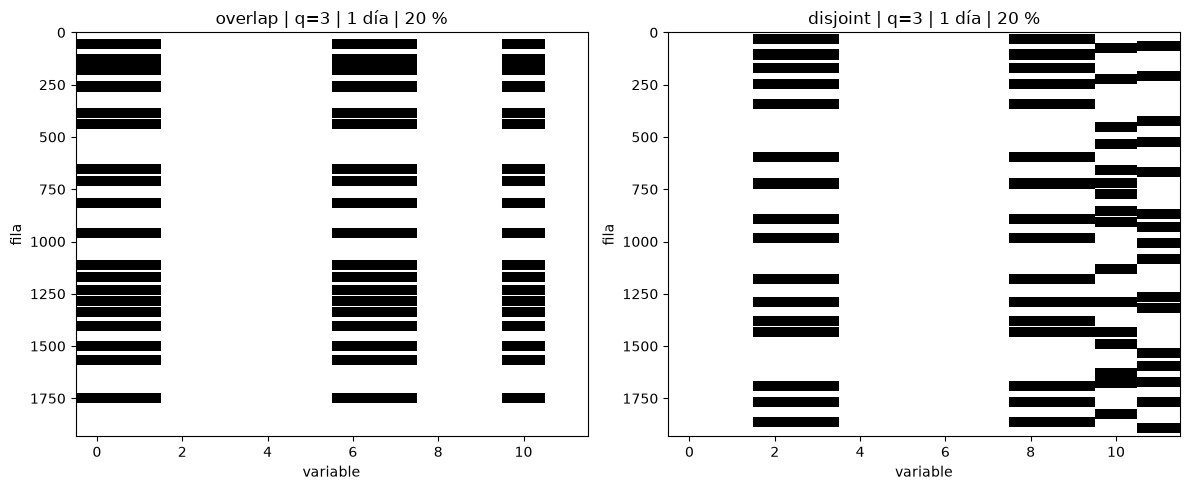

In [4]:
def longitudes(col):
    c = np.concatenate([[0], col.astype(int), [0]])
    d = np.diff(c)
    return np.where(d == -1)[0] - np.where(d == 1)[0]

def verificar(info, masc):
    err = (info["pct_real"] - info["pct_objetivo"]).abs()
    ok_long, simult = [], []
    for _, f in info.iterrows():
        mk = masc[f["id"]]
        cols = mk.any(axis=0)
        ok_long.append(all((longitudes(mk[:, j]) == f["filas_bloque"]).all() for j in np.where(cols)[0]))
        n = mk[:, cols].sum(axis=1)
        simult.append(n[n > 0].mean() / cols.sum())
    info = info.assign(bloques_ok=ok_long, simultaneidad=simult)
    print("Error máximo entre % objetivo y % real:", round(err.max(), 2), "puntos")
    print("Todos los bloques miden exactamente p filas:", bool(info["bloques_ok"].all()))
    print(info.groupby("patron")["simultaneidad"].agg(["mean", "min", "max"]).round(2))
    return info

info_aj = verificar(info_aj, masc_aj)

fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
for ax, patron in zip(ejes, PATRONES):
    f = info_aj[(info_aj.patron == patron) & (info_aj.q == 3) & (info_aj.duracion == "1d") & (info_aj.pct_objetivo == 20)].iloc[0]
    ax.imshow(masc_aj[f["id"]], aspect="auto", cmap="Greys", interpolation="nearest")
    ax.set_title(f"{patron} | q=3 | 1 día | 20 %"); ax.set_xlabel("variable"); ax.set_ylabel("fila")
plt.tight_layout()
plt.show()